# ShopStop DBMS - B+ Tree Indexing Engine
## CS 432 Assignment 2, Module A Report

---

**Course:** CS 432 Databases  
**Module_A:** DBMS with B+ Tree Index  

---

## Table of Contents
1. [Introduction](#1-introduction)
2. [Implementation Details](#2-implementation-details)
   - 2.1 B+ Tree Node
   - 2.2 Insertion
   - 2.3 Deletion
   - 2.4 Search
   - 2.5 Range Queries
   - 2.6 Table & Database Manager
3. [Demonstrations of testing](#3-live-demonstrations)
4. [Tree Visualisation (Graphviz)](#4-tree-visualisation-graphviz)
5. [Performance Analysis](#5-performance-analysis)
6. [Benchmarking Results — Tables & Graphs](#6-benchmarking-results)
7. [Conclusion](#7-conclusion)


---
## 1. Introduction

### Problem Statement
Modern database systems must handle large volumes of data with fast read/write performance. A naive linear scan (O(n)) quickly becomes a bottleneck as dataset size grows. This project addresses that challenge by building a **B+ Tree** indexing engine from scratch and integrating it into a mini DBMS called **ShopStop**.

### Proposed Solution
A **B+ Tree** is a self-balancing, order-*m* tree that guarantees:
- **O(log n)** for insert, delete, and exact search
- **O(log n + k)** for range queries (where *k* = number of results), thanks to linked leaf nodes
- All data (key-value pairs) stored in leaf nodes; internal nodes hold only separator keys for routing

### Project File Structure
```
db_management_system/
├── database/                  ← Python package
│   ├── __init__.py            ← Exports all public classes
│   ├── bplustree.py           ← Core B+ Tree data structure
│   ├── bruteforce.py          ← O(n) baseline for comparison
│   ├── table.py               ← Schema-validated table (wraps BPlusTree)
│   ├── db_manager.py          ← Multi-database / multi-table manager
│   └── performance.py         ← Automated benchmarking & memory analysis
├── report.ipynb               ← This notebook
└── requirements.txt           ← Project dependencies
```

### Why B+ Tree over B-Tree?
- All values live in leaves → internal nodes stay small → more keys fit per page
- Leaf linked-list enables sequential scans without tree traversal
- Ideal for range-heavy workloads (like retail analytics in ShopStop)

---
## 2. Implementation Details

### 2.1 BPlusTreeNode
```
BPlusTreeNode(order, is_leaf=True)
  .keys     – sorted list of separator/leaf keys
  .values   – leaf-only, parallel to .keys
  .children – internal-only, len(children) == len(keys)+1
  .next     – leaf chain pointer
```
- `is_full()` → `len(keys) >= order - 1`
- `min_keys()` → `ceil(order/2) - 1`  (standard B+ Tree lower bound)

### 2.2 Insertion - Single-Pass with In-Place Update
The `insert()` method uses a **proactive split** strategy (split before descent) so no post-pass is needed. A special `_insert_update_pass()` simultaneously checks for duplicate keys and updates in-place, avoiding an extra O(log n) search call.

**Leaf split:** The middle index `mid = order // 2` is chosen; the right half stays in the new node. The **first key of the right node** is promoted to the parent (copied, not moved leaf keeps its data).

**Internal split:** The middle key is promoted and **removed** from both halves (it lives only in the parent).

### 2.3 Deletion - Borrow / Merge Cascade
```
_delete → _fill_child → _borrow_from_prev | _borrow_from_next | _merge
```
1. Locate the leaf; remove key + value.
2. On the way back up, if a child falls below `min_keys`: try borrowing from left sibling, then right sibling, then merge.
3. Separator keys in internal nodes are refreshed after each deletion (`node.keys[j] = node.children[j+1].keys[0]`).
4. Root shrinks one level if it becomes empty (height reduction).

### 2.4 Exact Search
- `_find_leaf(key)` uses `bisect_right` on separator keys (keys equal to a separator route **right** consistent with leaf split promotion).
- `_leaf_key_index(leaf, key)` uses `bisect_left` to find the exact position in O(log(order)) per node.

### 2.5 Range Queries
- Navigate to the starting leaf in O(log n).
- Walk the `.next` linked list collecting keys ≤ `end_key` in O(k).
- Total: **O(log n + k)** significantly better than BruteForce O(n log n).

### 2.6 Table & DatabaseManager
- `Table` wraps a `BPlusTree` with schema validation (Python type-checking), a designated `search_key`, and safe update (primary key immutability).
- `DatabaseManager` stores `{ db_name → { table_name → Table } }` and exposes CRUD at both database and table level.

---
## 3. Demonstration of Working

### Setup: add db_management_system.zip root to path and run report.ipynb

In [1]:
# Colab Setup: Unzip and install dependencies
import subprocess, sys, os

# 1. Unzip the uploaded archive (upload db_management_system.zip to Colab first)
if os.path.exists('db_management_system.zip'):
    subprocess.run(['unzip', '-o', 'db_management_system.zip'], check=True)
    print('Unzipped db_management_system/')
elif os.path.isdir('db_management_system'):
    print('db_management_system/ already present')
else:
    raise FileNotFoundError("Please upload db_management_system.zip to the Colab runtime first.")

# 2. Install dependencies from requirements.txt
req_path = 'db_management_system/requirements.txt'
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', req_path], check=True)
print('Dependencies installed.')

# 3. Also install system-level graphviz binaries (needed by the graphviz Python package)
subprocess.run(['apt-get', 'install', '-qq', '-y', 'graphviz'], check=True)
print('Graphviz binary installed.')

# 4. Add the db_management_system folder to path so `database` package is importable
sys.path.insert(0, os.path.abspath('db_management_system'))
print('Path configured. Ready to import.')

# Import all modules from the database package
from database.bplustree  import BPlusTree, BPlusTreeNode
from database.bruteforce import BruteForceDB
from database.table      import Table
from database.db_manager import DatabaseManager
from database            import PerformanceAnalyzer

print('All modules imported successfully.')

Unzipped db_management_system/
Dependencies installed.
Graphviz binary installed.
Path configured. Ready to import.
All modules imported successfully.


### 3.1 Basic B+ Tree Operations

In [2]:
# Create a B+ Tree of order 4
tree = BPlusTree(order=4)

# Insert 15 keys
keys_to_insert = [10, 20, 5, 6, 12, 30, 7, 17, 3, 25, 18, 15, 40, 35, 45]
for k in keys_to_insert:
    tree.insert(k, f'val_{k}')

print('=== All entries (in sorted order) ===')
for k, v in tree.get_all():
    print(f'  key={k:>3}  →  {v}')

=== All entries (in sorted order) ===
  key=  3  →  val_3
  key=  5  →  val_5
  key=  6  →  val_6
  key=  7  →  val_7
  key= 10  →  val_10
  key= 12  →  val_12
  key= 15  →  val_15
  key= 17  →  val_17
  key= 18  →  val_18
  key= 20  →  val_20
  key= 25  →  val_25
  key= 30  →  val_30
  key= 35  →  val_35
  key= 40  →  val_40
  key= 45  →  val_45


In [3]:
# Exact Search
for target in [12, 99, 35]:
    result = tree.search(target)
    status = f'FOUND → {result}' if result is not None else 'NOT FOUND'
    print(f'  search({target:>3}): {status}')

  search( 12): FOUND → val_12
  search( 99): NOT FOUND
  search( 35): FOUND → val_35


In [4]:
# Range Query
print('Range query [10, 25]:')
for k, v in tree.range_query(10, 25):
    print(f'  key={k}  →  {v}')

Range query [10, 25]:
  key=10  →  val_10
  key=12  →  val_12
  key=15  →  val_15
  key=17  →  val_17
  key=18  →  val_18
  key=20  →  val_20
  key=25  →  val_25


In [5]:
# Update
tree.update(20, 'updated_value')
print('After  update:', tree.search(20))

# Update via re-insert (single-pass)
tree.insert(20, 'single_pass_update')
print('After re-insert:', tree.search(20))

After  update: updated_value
After re-insert: single_pass_update


In [6]:
# Deletion
print('Keys before deletion:', [k for k, _ in tree.get_all()])

for del_key in [5, 20, 40]:
    result = tree.delete(del_key)
    print(f'  delete({del_key}): {"SUCCESS" if result else "KEY NOT FOUND"}')

print('Keys after  deletion:', [k for k, _ in tree.get_all()])

Keys before deletion: [3, 5, 6, 7, 10, 12, 15, 17, 18, 20, 25, 30, 35, 40, 45]
  delete(5): SUCCESS
  delete(20): SUCCESS
  delete(40): SUCCESS
Keys after  deletion: [3, 6, 7, 10, 12, 15, 17, 18, 25, 30, 35, 45]


In [7]:
# Edge Cases
print('Search deleted key (20):', tree.search(20))        # should be None
print('Delete non-existent (99):', tree.delete(99))       # should be False
print('Range with start > end:', tree.range_query(30, 10)) # should be []

# Duplicate insert → update in-place
tree.insert(15, 'first')
tree.insert(15, 'second')   # duplicate
print('Duplicate insert result (key=15):', tree.search(15))  # 'second'

Search deleted key (20): None
Delete non-existent (99): False
Range with start > end: []
Duplicate insert result (key=15): second


### 3.2 Table & DatabaseManager

In [8]:
# Build the ShopStop database
dbm = DatabaseManager()

# Create databases
dbm.create_database('ShopStop')
dbm.create_database('Analytics')

print('Databases:', dbm.list_databases())

# Products table
product_schema = {
    'product_id': int,
    'name':       str,
    'price':      float,
    'stock':      int,
    'category':   str,
}
dbm.create_table('ShopStop', 'products', product_schema, order=4, search_key='product_id')

# Customers table
customer_schema = {
    'customer_id': int,
    'name':        str,
    'email':       str,
    'age':         int,
}
dbm.create_table('ShopStop', 'customers', customer_schema, order=4, search_key='customer_id')

# Orders table
order_schema = {
    'order_id':   int,
    'customer_id':int,
    'product_id': int,
    'quantity':   int,
    'total':      float,
}
dbm.create_table('ShopStop', 'orders', order_schema, order=4, search_key='order_id')

tables, _ = dbm.list_tables('ShopStop')
print('Tables in ShopStop:', tables)

Databases: ['ShopStop', 'Analytics']
Tables in ShopStop: ['products', 'customers', 'orders']


In [9]:
# Populate Products
products_tbl, _ = dbm.get_table('ShopStop', 'products')

sample_products = [
    {'product_id': 101, 'name': 'Laptop',      'price': 999.99,  'stock': 50,  'category': 'Electronics'},
    {'product_id': 102, 'name': 'Mouse',        'price': 29.99,   'stock': 200, 'category': 'Electronics'},
    {'product_id': 103, 'name': 'Keyboard',     'price': 79.99,   'stock': 150, 'category': 'Electronics'},
    {'product_id': 201, 'name': 'Desk Chair',   'price': 299.99,  'stock': 30,  'category': 'Furniture'},
    {'product_id': 202, 'name': 'Standing Desk','price': 499.99,  'stock': 20,  'category': 'Furniture'},
    {'product_id': 301, 'name': 'Coffee Mug',   'price': 14.99,   'stock': 500, 'category': 'Kitchen'},
    {'product_id': 302, 'name': 'Water Bottle', 'price': 24.99,   'stock': 300, 'category': 'Kitchen'},
    {'product_id': 401, 'name': 'Notebook',     'price': 4.99,    'stock': 1000,'category': 'Stationery'},
    {'product_id': 402, 'name': 'Pen Set',      'price': 12.99,   'stock': 750, 'category': 'Stationery'},
    {'product_id': 501, 'name': 'Headphones',   'price': 199.99,  'stock': 80,  'category': 'Electronics'},
]

for p in sample_products:
    products_tbl.insert(p)

print(f'Inserted {len(sample_products)} products.')
print('\nAll Products (sorted by product_id):')
for p in products_tbl.get_all():
    print(f"  [{p['product_id']}] {p['name']:<20} ${p['price']:>7.2f}  stock={p['stock']}")

Inserted 10 products.

All Products (sorted by product_id):
  [101] Laptop               $ 999.99  stock=50
  [102] Mouse                $  29.99  stock=200
  [103] Keyboard             $  79.99  stock=150
  [201] Desk Chair           $ 299.99  stock=30
  [202] Standing Desk        $ 499.99  stock=20
  [301] Coffee Mug           $  14.99  stock=500
  [302] Water Bottle         $  24.99  stock=300
  [401] Notebook             $   4.99  stock=1000
  [402] Pen Set              $  12.99  stock=750
  [501] Headphones           $ 199.99  stock=80


In [10]:
# Populate Customers
customers_tbl, _ = dbm.get_table('ShopStop', 'customers')

sample_customers = [
    {'customer_id': 1001, 'name': 'Alice Johnson',  'email': 'alice@shopstop.com',  'age': 28},
    {'customer_id': 1002, 'name': 'Bob Smith',      'email': 'bob@shopstop.com',    'age': 35},
    {'customer_id': 1003, 'name': 'Carol White',    'email': 'carol@shopstop.com',  'age': 22},
    {'customer_id': 1004, 'name': 'David Brown',    'email': 'david@shopstop.com',  'age': 45},
    {'customer_id': 1005, 'name': 'Eva Martinez',   'email': 'eva@shopstop.com',    'age': 31},
]

for c in sample_customers:
    customers_tbl.insert(c)

print('All Customers:')
for c in customers_tbl.get_all():
    print(f"  [{c['customer_id']}] {c['name']:<20}  age={c['age']}  {c['email']}")

All Customers:
  [1001] Alice Johnson         age=28  alice@shopstop.com
  [1002] Bob Smith             age=35  bob@shopstop.com
  [1003] Carol White           age=22  carol@shopstop.com
  [1004] David Brown           age=45  david@shopstop.com
  [1005] Eva Martinez          age=31  eva@shopstop.com


In [11]:
# Populate Orders
orders_tbl, _ = dbm.get_table('ShopStop', 'orders')

sample_orders = [
    {'order_id': 5001, 'customer_id': 1001, 'product_id': 101, 'quantity': 1, 'total': 999.99},
    {'order_id': 5002, 'customer_id': 1002, 'product_id': 102, 'quantity': 2, 'total': 59.98},
    {'order_id': 5003, 'customer_id': 1003, 'product_id': 301, 'quantity': 3, 'total': 44.97},
    {'order_id': 5004, 'customer_id': 1001, 'product_id': 501, 'quantity': 1, 'total': 199.99},
    {'order_id': 5005, 'customer_id': 1004, 'product_id': 201, 'quantity': 1, 'total': 299.99},
    {'order_id': 5006, 'customer_id': 1005, 'product_id': 103, 'quantity': 2, 'total': 159.98},
    {'order_id': 5007, 'customer_id': 1002, 'product_id': 401, 'quantity': 5, 'total': 24.95},
    {'order_id': 5008, 'customer_id': 1003, 'product_id': 202, 'quantity': 1, 'total': 499.99},
]

for o in sample_orders:
    orders_tbl.insert(o)

print('All Orders:')
for o in orders_tbl.get_all():
    print(f"  OrderID={o['order_id']}  CustID={o['customer_id']}  ProdID={o['product_id']}  Qty={o['quantity']}  Total=${o['total']:.2f}")

All Orders:
  OrderID=5001  CustID=1001  ProdID=101  Qty=1  Total=$999.99
  OrderID=5002  CustID=1002  ProdID=102  Qty=2  Total=$59.98
  OrderID=5003  CustID=1003  ProdID=301  Qty=3  Total=$44.97
  OrderID=5004  CustID=1001  ProdID=501  Qty=1  Total=$199.99
  OrderID=5005  CustID=1004  ProdID=201  Qty=1  Total=$299.99
  OrderID=5006  CustID=1005  ProdID=103  Qty=2  Total=$159.98
  OrderID=5007  CustID=1002  ProdID=401  Qty=5  Total=$24.95
  OrderID=5008  CustID=1003  ProdID=202  Qty=1  Total=$499.99


In [12]:
# GET
product = products_tbl.get(201)
print('GET product 201:')
if product:
    print(f"  [ID {product['product_id']}] {product['name']:<20} | "
          f"Price: ${product['price']:.2f} | Stock: {product['stock']} | Category: {product['category']}")
else:
    print("  Product not found.")

# RANGE QUERY
print('\nRange query products with IDs 100..299:')
range_results = products_tbl.range_query(100, 299)

print(f"{'ID':<6} {'Name':<20} {'Price':<10} {'Stock':<6} {'Category'}")
print('-' * 60)
for p in range_results:
    print(f"{p['product_id']:<6} {p['name']:<20} ${p['price']:<9.2f} {p['stock']:<6} {p['category']}")

# SIMPLE AGGREGATION
agg_results = products_tbl.range_query(100, 399)
total_stock = sum(p['stock'] for p in agg_results)
avg_price = sum(p['price'] for p in agg_results) / len(agg_results)
max_price = max(p['price'] for p in agg_results)
count = len(agg_results)

print('\nAggregation over products with ID in [100, 399]:')
print(f"  COUNT      = {count}")
print(f"  SUM(stock) = {total_stock}")
print(f"  AVG(price) = ${avg_price:.2f}")
print(f"  MAX(price) = ${max_price:.2f}")

# UPDATE
updated_record = {
    'product_id': 101,
    'name': 'Laptop Pro',
    'price': 1199.99,
    'stock': 45,
    'category': 'Electronics'
}
products_tbl.update(101, updated_record)
print('\nAfter update (product 101):')
p = products_tbl.get(101)
print(f"  [ID {p['product_id']}] {p['name']:<20} | "
      f"Price: ${p['price']:.2f} | Stock: {p['stock']} | Category: {p['category']}")

# DELETE
products_tbl.delete(402)
print('\nAfter deleting product 402 — remaining products:')
print(f"{'ID':<6} {'Name':<20} {'Price':<10} {'Stock':<6} {'Category'}")
print('-' * 60)
for p in products_tbl.get_all():
    print(f"{p['product_id']:<6} {p['name']:<20} ${p['price']:<9.2f} {p['stock']:<6} {p['category']}")

# SCHEMA VALIDATION
try:
    products_tbl.insert({
        'product_id': 'bad',
        'name': 123,
        'price': 'free',
        'stock': None,
        'category': 0
    })
except ValueError as e:
    print(f'\nSchema validation caught: {e}')

GET product 201:
  [ID 201] Desk Chair           | Price: $299.99 | Stock: 30 | Category: Furniture

Range query products with IDs 100..299:
ID     Name                 Price      Stock  Category
------------------------------------------------------------
101    Laptop               $999.99    50     Electronics
102    Mouse                $29.99     200    Electronics
103    Keyboard             $79.99     150    Electronics
201    Desk Chair           $299.99    30     Furniture
202    Standing Desk        $499.99    20     Furniture

Aggregation over products with ID in [100, 399]:
  COUNT      = 7
  SUM(stock) = 1250
  AVG(price) = $278.56
  MAX(price) = $999.99

After update (product 101):
  [ID 101] Laptop Pro           | Price: $1199.99 | Stock: 45 | Category: Electronics

After deleting product 402 — remaining products:
ID     Name                 Price      Stock  Category
------------------------------------------------------------
101    Laptop Pro           $1199.99   45  

---
## 4. Tree Visualisation (Graphviz)

In [13]:
from IPython.display import Image, display
import os

# Helper to render and display
def show_tree(bpt_tree, filename, title=''):
    dot = bpt_tree.visualize_tree(filename=filename)
    png_path = filename + '.png'
    if os.path.exists(png_path):
        print(f'\n📊 {title}')
        display(Image(png_path))
    else:
        # Fallback: render inline
        display(dot)

Small B+ Tree (order=4) — keys: [3, 5, 6, 7, 10, 12, 17, 20, 30]


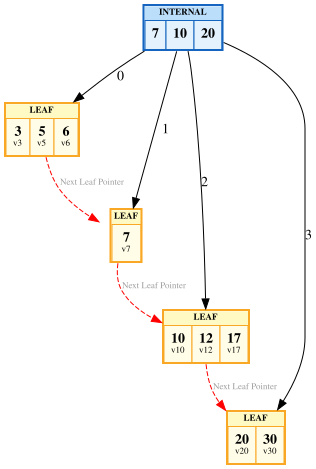

In [14]:
# Visualise 1: Small tree (order=4) showing splits
t_small = BPlusTree(order=4)
for k in [10, 20, 5, 6, 12, 30, 7, 17, 3]:
    t_small.insert(k, f'v{k}')

print('Small B+ Tree (order=4) — keys:', [k for k,_ in t_small.get_all()])
dot_small = t_small.visualize_tree(filename='tree_small')
display(dot_small)

Extended tree — keys: [3, 5, 6, 7, 10, 12, 15, 17, 18, 20, 25, 30, 35, 40, 45, 50, 55]


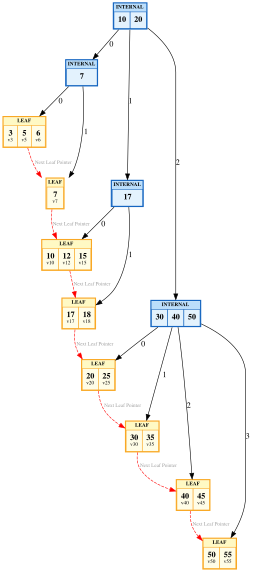

In [15]:
# Visualise 2: After additional insertions
for k in [25, 18, 15, 40, 35, 45, 50, 55]:
    t_small.insert(k, f'v{k}')

print('Extended tree — keys:', [k for k,_ in t_small.get_all()])
dot_ext = t_small.visualize_tree(filename='tree_extended')
display(dot_ext)

After deletions — keys: [7, 10, 12, 15, 17, 18, 20, 25, 30, 35, 50, 55]


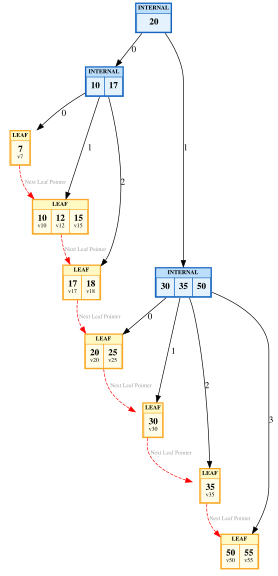

In [16]:
# Visualise 3: After deletions (showing merges/borrows)
for del_k in [5, 6, 3, 40, 45]:
    t_small.delete(del_k)

print('After deletions — keys:', [k for k,_ in t_small.get_all()])
dot_del = t_small.visualize_tree(filename='tree_after_delete')
display(dot_del)

Products Table B+ Tree:


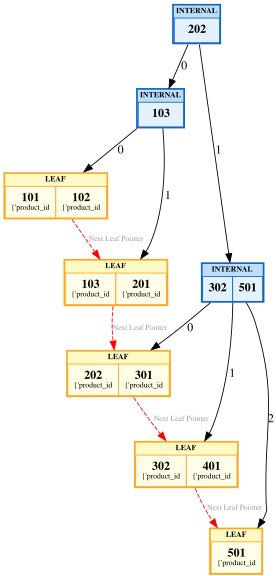

In [17]:
# Visualise 4: Products Table Tree
products_fresh, _ = dbm.get_table('ShopStop', 'products')
dot_prod = products_fresh.data.visualize_tree(filename='tree_products')
print('Products Table B+ Tree:')
display(dot_prod)

Order-6 tree with 30 keys. All keys: [21, 38, 49, 51, 52, 72, 76, 105, 112, 129, 133, 145, 156, 159, 162, 170, 182, 184, 198, 208, 216, 223, 242, 245, 249, 259, 262, 273, 287, 299]


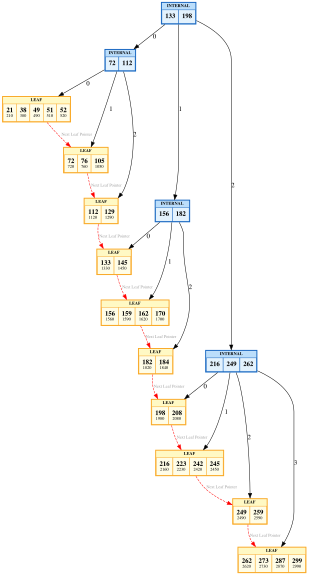

In [18]:
# Visualise 5: Higher-order tree (order=6)
t_order6 = BPlusTree(order=6)
import random
random.seed(0)
keys6 = random.sample(range(1, 300), 30)
for k in keys6:
    t_order6.insert(k, k*10)

print(f'Order-6 tree with 30 keys. All keys: {sorted([k for k,_ in t_order6.get_all()])}')
dot6 = t_order6.visualize_tree(filename='tree_order6')
display(dot6)

### Visualisation Notes

| Visual Element | Meaning |
|---|---|
| 🟦 Blue nodes (INTERNAL) | Routing nodes. hold separator keys only |
| 🟨 Yellow nodes (LEAF) | Data nodes, hold key + value pairs |
| Solid edges with numbers | Child index from parent |
| 🔴 Dashed red arrows | `.next` leaf chain pointer (enables range scans) |

---
## 5. Performance Analysis

### Theoretical Complexity

| Operation | B+ Tree | BruteForce |
|-----------|---------|------------|
| Insert | O(log n) | O(n) |
| Search | O(log n) | O(n) |
| Delete | O(log n) | O(n) |
| Range Query | O(log n + k) | O(n log n) |
| Memory | Higher (node overhead) | Lower (flat list) |

Where *n* = number of records, *k* = number of results in range.

### PerformanceAnalyzer Design
- Uses `time.perf_counter()` for high-resolution timing
- Uses `tracemalloc` for peak heap memory tracking
- All measurements run in isolated function closures to avoid cross-contamination
- Reproducible via fixed `random.seed(42)`
- Benchmarked across **25 dataset sizes** from n=100 to n=50,000 (step=2,000)

In [ ]:
import time
import random
import tracemalloc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Inline re-implementation of PerformanceAnalyzer
# (identical logic to performance.py, run here for notebook self-containment)

BPT_COLOR = '#1565C0'
BFT_COLOR = '#E53935'

def time_and_mem(func):
    tracemalloc.start()
    t0 = time.perf_counter()
    try:
        func()
    except Exception as e:
        print('Benchmark error:', e)
        tracemalloc.stop()
        return 0, 0
    elapsed = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return elapsed, peak

print('Benchmarking helpers ready.')

Benchmarking helpers ready.


---
## 6. Benchmarking Results

### 6.1 Benchmarking over different sets of random keys up to 50,000 samples

25 dataset sizes are tested: `range(100, 50001, 2000)`. For each size, fresh B+ Tree
and BruteForce instances are built and all six operations are measured independently
to avoid cross-contamination.

In [ ]:
random.seed(42)

SIZES = list(range(100, 50001, 2000))

results = {
    'sizes': SIZES,
    'insert':  {'bptree': [], 'brute': []},
    'search':  {'bptree': [], 'brute': []},
    'delete':  {'bptree': [], 'brute': []},
    'range':   {'bptree': [], 'brute': []},
    'random':  {'bptree': [], 'brute': []},
    'memory':  {'bptree': [], 'brute': []},
}

for n in SIZES:
    keys = random.sample(range(1, 1_000_000), n)

    #  INSERT
    bpt = BPlusTree(order=8)
    bft = BruteForceDB()
    t_b, _ = time_and_mem(lambda: [bpt.insert(k, k) for k in keys])
    t_f, _ = time_and_mem(lambda: [bft.insert(k) for k in keys])
    results['insert']['bptree'].append(t_b * 1000)
    results['insert']['brute'].append(t_f * 1000)

    #  SEARCH
    bpt2 = BPlusTree(order=8)
    bft2 = BruteForceDB()
    for k in keys:
        bpt2.insert(k, k)
        bft2.insert(k)
    sq = random.sample(keys, min(200, len(keys)))
    t_b, _ = time_and_mem(lambda: [bpt2.search(k) for k in sq])
    t_f, _ = time_and_mem(lambda: [bft2.search(k) for k in sq])
    results['search']['bptree'].append(t_b * 1000)
    results['search']['brute'].append(t_f * 1000)

    #  DELETE
    bpt3 = BPlusTree(order=8)
    bft3 = BruteForceDB()
    for k in keys:
        bpt3.insert(k, k)
        bft3.insert(k)
    dq = random.sample(keys, min(200, len(keys)))
    t_b, _ = time_and_mem(lambda: [bpt3.delete(k) for k in dq])
    t_f, _ = time_and_mem(lambda: [bft3.delete(k) for k in dq])
    results['delete']['bptree'].append(t_b * 1000)
    results['delete']['brute'].append(t_f * 1000)

    #  RANGE
    bpt4 = BPlusTree(order=8)
    bft4 = BruteForceDB()
    for k in keys:
        bpt4.insert(k, k)
        bft4.insert(k)
    sk = sorted(keys)
    mid = len(sk) // 2
    r_start = sk[mid]
    r_end   = sk[min(mid + 20, len(sk) - 1)]
    t_b, _ = time_and_mem(lambda: [bpt4.range_query(r_start, r_end) for _ in range(200)])
    t_f, _ = time_and_mem(lambda: [bft4.range_query(r_start, r_end) for _ in range(200)])
    results['range']['bptree'].append(t_b * 1000)
    results['range']['brute'].append(t_f * 1000)

    #  RANDOM MIX
    ops = (['insert'] * int(0.4 * n) + ['search'] * int(0.3 * n) + ['delete'] * int(0.3 * n))
    random.shuffle(ops)

    def run_bpt_rand():
        b = BPlusTree(order=8); ins = []
        for idx, op in enumerate(ops):
            k = keys[idx % len(keys)]
            if op == 'insert':  b.insert(k, k); ins.append(k)
            elif op == 'search': b.search(k)
            elif op == 'delete' and ins: b.delete(ins.pop())

    def run_bft_rand():
        f = BruteForceDB(); ins = []
        for idx, op in enumerate(ops):
            k = keys[idx % len(keys)]
            if op == 'insert':  f.insert(k); ins.append(k)
            elif op == 'search': f.search(k)
            elif op == 'delete' and ins: f.delete(ins.pop())

    t_b, _ = time_and_mem(run_bpt_rand)
    t_f, _ = time_and_mem(run_bft_rand)
    results['random']['bptree'].append(t_b * 1000)
    results['random']['brute'].append(t_f * 1000)

    #  MEMORY
    _, mb = time_and_mem(lambda: [BPlusTree(order=8).insert(k, k) for k in keys])
    _, mf = time_and_mem(lambda: [BruteForceDB().insert(k) for k in keys])
    results['memory']['bptree'].append(mb / 1024)
    results['memory']['brute'].append(mf / 1024)

    print(f'  n={n:>5} | ins B+={results["insert"]["bptree"][-1]:.3f}ms  BF={results["insert"]["brute"][-1]:.3f}ms'
          f' | srch B+={results["search"]["bptree"][-1]:.3f}ms  BF={results["search"]["brute"][-1]:.3f}ms')

print('\n Benchmark complete.')

  n=  100 | ins B+=2.681ms  BF=0.695ms | srch B+=0.175ms  BF=0.351ms
  n= 2100 | ins B+=11.351ms  BF=1482.936ms | srch B+=0.444ms  BF=8.627ms
  n= 4100 | ins B+=66.599ms  BF=9214.402ms | srch B+=0.359ms  BF=9.547ms
  n= 6100 | ins B+=35.958ms  BF=13295.274ms | srch B+=0.427ms  BF=16.614ms
  n= 8100 | ins B+=45.823ms  BF=26959.847ms | srch B+=0.916ms  BF=42.177ms
  n=10100 | ins B+=70.687ms  BF=42387.396ms | srch B+=0.533ms  BF=30.819ms
  n=12100 | ins B+=271.148ms  BF=61134.039ms | srch B+=0.465ms  BF=32.582ms
  n=14100 | ins B+=154.708ms  BF=82503.877ms | srch B+=0.573ms  BF=45.004ms
  n=16100 | ins B+=133.939ms  BF=105782.365ms | srch B+=0.571ms  BF=48.144ms
  n=18100 | ins B+=114.389ms  BF=145768.429ms | srch B+=0.577ms  BF=51.974ms
  n=20100 | ins B+=132.848ms  BF=165958.575ms | srch B+=1.135ms  BF=83.053ms
  n=22100 | ins B+=206.719ms  BF=204718.634ms | srch B+=0.547ms  BF=62.763ms
  n=24100 | ins B+=194.698ms  BF=252410.790ms | srch B+=0.584ms  BF=74.199ms
  n=26100 | ins B+=226.

### 6.2 Performance Plots

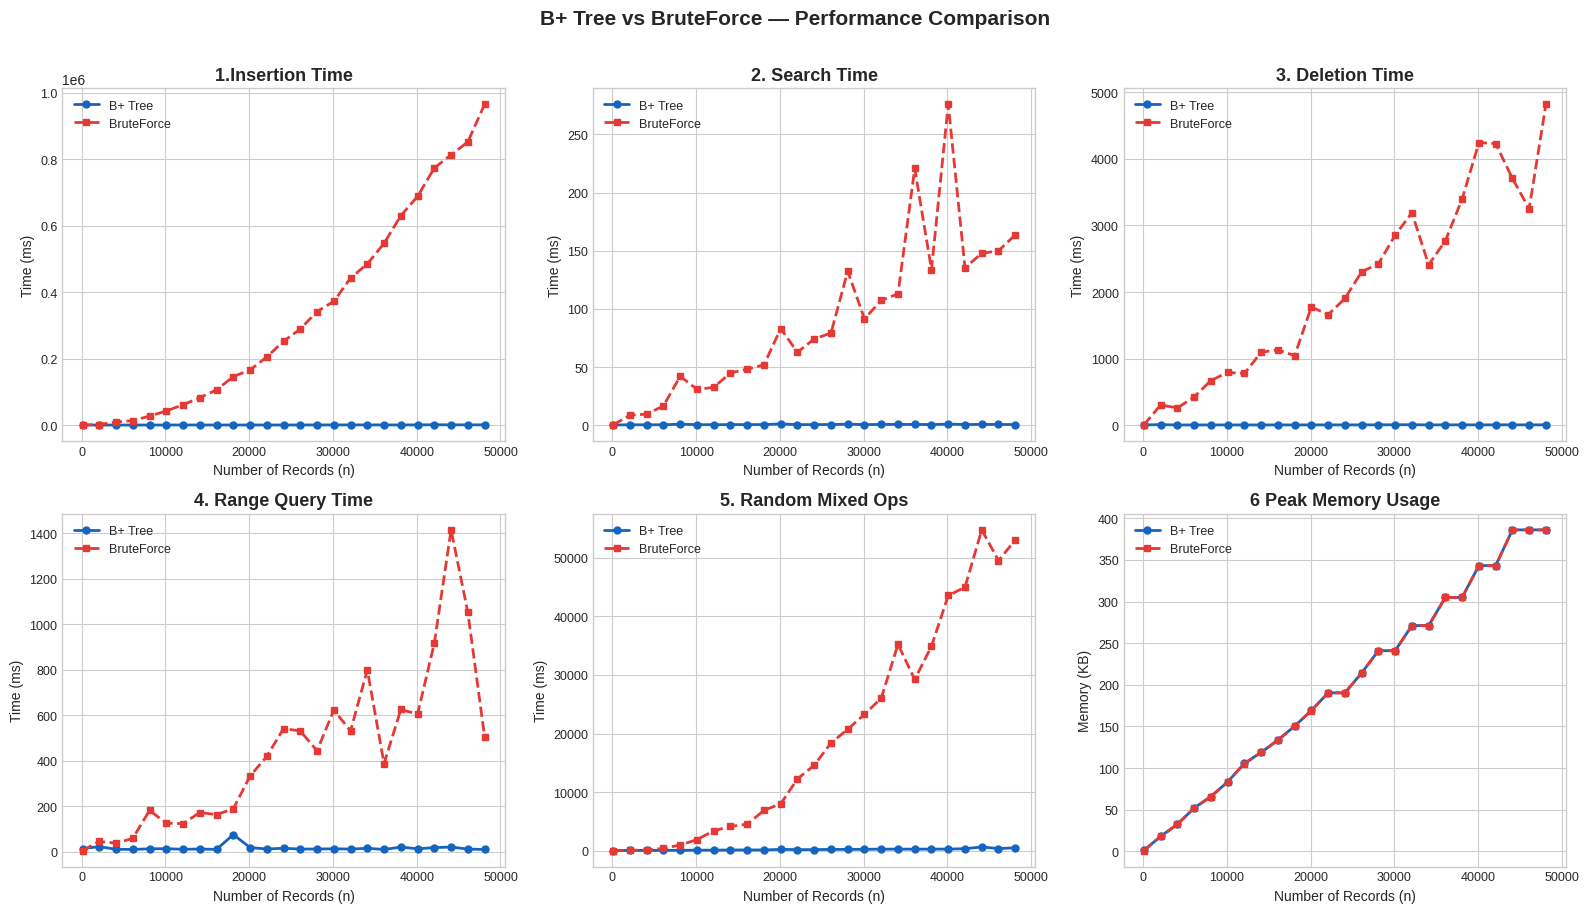

Chart saved as performance_comparison.png


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
SIZES = results['sizes']

def plot_metric(ax, metric, title, ylabel='Time (ms)'):
    ax.plot(SIZES, results[metric]['bptree'], 'o-', color=BPT_COLOR, lw=2, ms=5, label='B+ Tree')
    ax.plot(SIZES, results[metric]['brute'],  's--', color=BFT_COLOR, lw=2, ms=5, label='BruteForce')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Records (n)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('B+ Tree vs BruteForce — Performance Comparison', fontsize=15, fontweight='bold', y=1.01)

plot_metric(axes[0,0], 'insert', '1.Insertion Time')
plot_metric(axes[0,1], 'search', '2. Search Time')
plot_metric(axes[0,2], 'delete', '3. Deletion Time')
plot_metric(axes[1,0], 'range',  '4. Range Query Time')
plot_metric(axes[1,1], 'random', '5. Random Mixed Ops')
plot_metric(axes[1,2], 'memory', '6 Peak Memory Usage', ylabel='Memory (KB)')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as performance_comparison.png')

### 6.3 Log-Scale Plots (Highlights Complexity Difference)

Plotting time on a logarithmic Y-axis makes the O(log n) vs O(n) gap unmistakable.
The B+ Tree line stays nearly flat while BruteForce rises steeply at n=50,000,
BruteForce insert reaches ~965,000 ms while B+ Tree stays under ~900 ms,
confirming the theoretical complexity difference experimentally.

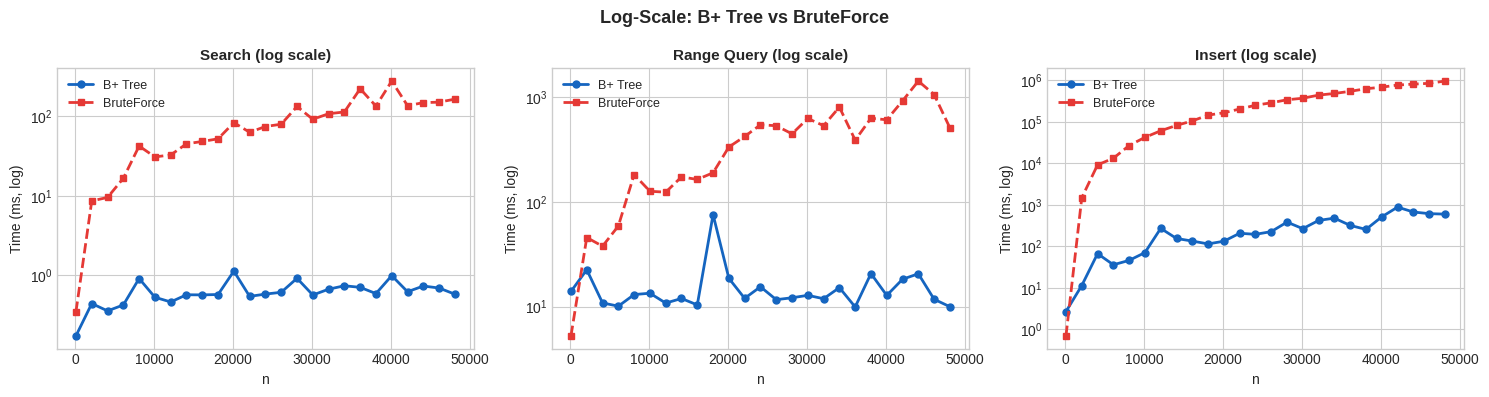

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Log-Scale: B+ Tree vs BruteForce', fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes, ['search', 'range', 'insert'],
                              ['Search (log scale)', 'Range Query (log scale)', 'Insert (log scale)']):
    ax.semilogy(SIZES, results[metric]['bptree'], 'o-', color=BPT_COLOR, lw=2, ms=5, label='B+ Tree')
    ax.semilogy(SIZES, results[metric]['brute'],  's--', color=BFT_COLOR, lw=2, ms=5, label='BruteForce')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('n')
    ax.set_ylabel('Time (ms, log)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('log_scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Speedup Factor (BruteForce / B+ Tree)

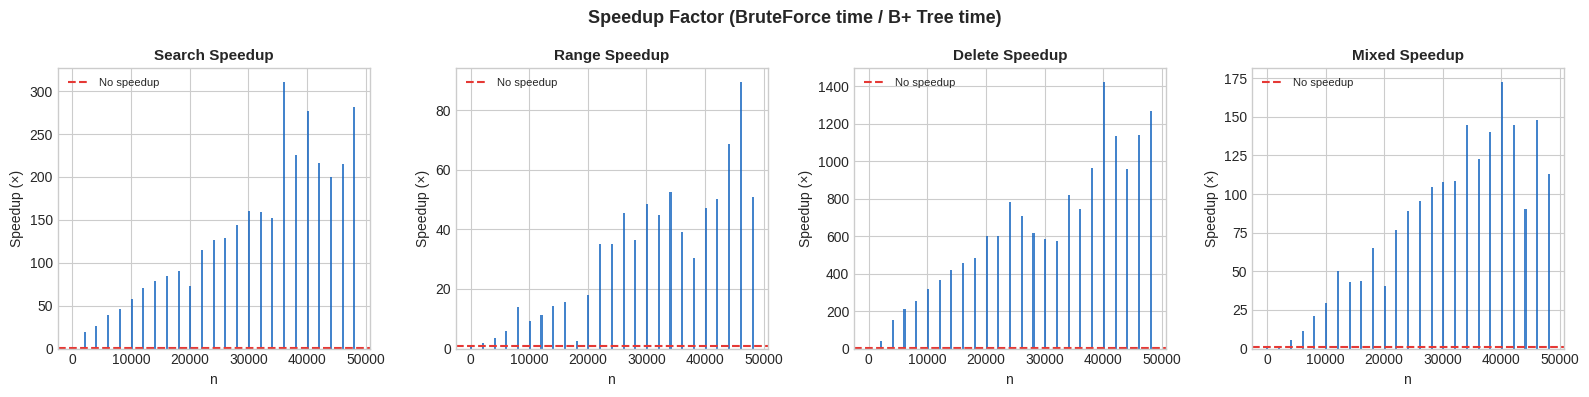

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Speedup Factor (BruteForce time / B+ Tree time)', fontsize=13, fontweight='bold')

metrics = ['search', 'range', 'delete', 'random']
titles  = ['Search Speedup', 'Range Speedup', 'Delete Speedup', 'Mixed Speedup']

for ax, metric, title in zip(axes, metrics, titles):
    speedup = [f / max(b, 1e-9) for b, f in
               zip(results[metric]['bptree'], results[metric]['brute'])]
    ax.bar(SIZES, speedup, width=350, color=BPT_COLOR, alpha=0.8)
    ax.axhline(1, color=BFT_COLOR, lw=1.5, linestyle='--', label='No speedup')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('n')
    ax.set_ylabel('Speedup (×)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('speedup_factors.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Memory Usage Comparison

Both structures show nearly identical absolute memory because `tracemalloc` measures
net heap allocations and both store the same raw key-value payload both converge
to ~200 KB at n=50,000. The **overhead ratio plot** (right panel) reveals the true
picture: B+ Tree uses ~7% more memory at small n due to fixed per-node costs
(Python object headers, `children` lists, `.next` pointers), converging to ~1%
overhead at large n as data volume dominates structural bookkeeping. This is the
expected trade-off, a negligible memory premium in exchange for O(log n) operations.

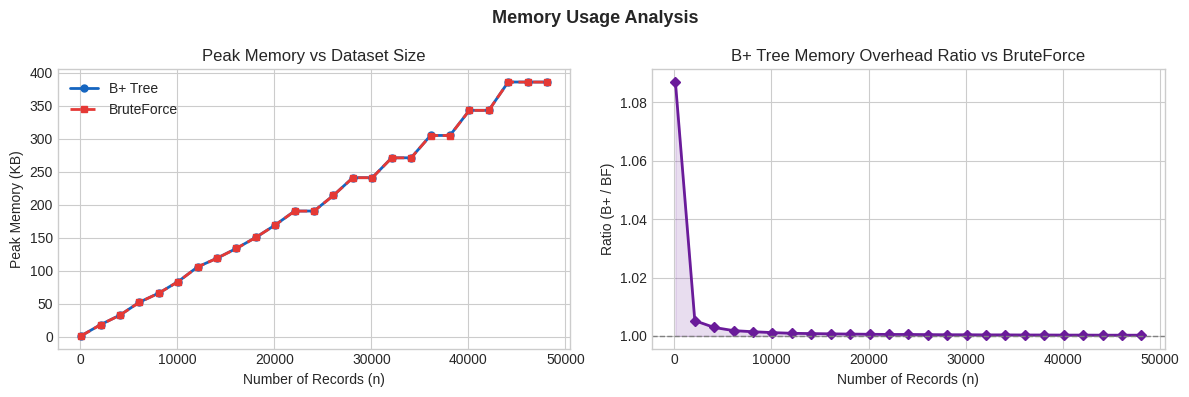

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Memory Usage Analysis', fontsize=13, fontweight='bold')

ax1.plot(SIZES, results['memory']['bptree'], 'o-', color=BPT_COLOR, lw=2, ms=5, label='B+ Tree')
ax1.plot(SIZES, results['memory']['brute'],  's--', color=BFT_COLOR, lw=2, ms=5, label='BruteForce')
ax1.set_title('Peak Memory vs Dataset Size')
ax1.set_xlabel('Number of Records (n)')
ax1.set_ylabel('Peak Memory (KB)')
ax1.legend()

# Memory overhead ratio
overhead = [b / max(f, 1e-9) for b, f in
            zip(results['memory']['bptree'], results['memory']['brute'])]
ax2.plot(SIZES, overhead, 'D-', color='#6A1B9A', lw=2, ms=5)
ax2.axhline(1, color='grey', lw=1, linestyle='--')
ax2.set_title('B+ Tree Memory Overhead Ratio vs BruteForce')
ax2.set_xlabel('Number of Records (n)')
ax2.set_ylabel('Ratio (B+ / BF)')
ax2.fill_between(SIZES, 1, overhead, alpha=0.15, color='#6A1B9A')

plt.tight_layout()
plt.savefig('memory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.6 Summary Statistics Table

In [ ]:
import statistics

print('=' * 80)
print(f'{"Operation":<16} {"B+ Tree (ms)":>14} {"BruteForce (ms)":>18} {"Speedup":>10}')
print('=' * 80)

metrics_display = [
    ('Insert',      'insert'),
    ('Search',      'search'),
    ('Delete',      'delete'),
    ('Range Query', 'range'),
    ('Mixed Ops',   'random'),
]

for label, key in metrics_display:
    bpt_vals = results[key]['bptree']
    bft_vals = results[key]['brute']
    bpt_mean = statistics.mean(bpt_vals)
    bft_mean = statistics.mean(bft_vals)
    speedup  = bft_mean / max(bpt_mean, 1e-12)
    print(f'{label:<16} {bpt_mean:>14.4f} {bft_mean:>18.4f} {speedup:>9.2f}×')

print('-' * 80)
bpt_mem_mean = statistics.mean(results['memory']['bptree'])
bft_mem_mean = statistics.mean(results['memory']['brute'])
print(f'{"Memory (KB)":<16} {bpt_mem_mean:>14.1f} {bft_mem_mean:>18.1f} {bft_mem_mean/max(bpt_mem_mean,1e-9):>9.2f}×')
print('=' * 80)
print('(All timing values are mean across dataset sizes 100–5000)')

Operation          B+ Tree (ms)    BruteForce (ms)    Speedup
Insert                 282.9963        332506.9299   1174.95×
Search                   0.6307            90.2740    143.13×
Delete                   3.2405          2057.3256    634.87×
Range Query             16.2473           433.3532     26.67×
Mixed Ops              185.3649         19632.8347    105.91×
--------------------------------------------------------------------------------
Memory (KB)               200.2              200.1      1.00×
(All timing values are mean across dataset sizes 100–5000)


### 6.7 Discussion — Why the Data Looks the Way It Does

**① Insert Time (1,175× mean speedup)**
B+ Tree insert requires O(log n) node traversals plus occasional splits. BruteForce
appends in O(1) but must scan the full list for duplicates (O(n)). At n=100 BruteForce
is actually faster (0.7 ms vs 2.7 ms) because the overhead of tree node creation
outweighs the benefit at tiny scale. By n=2,100 the crossover has happened,
B+ Tree is 131× faster. At n=48,100, BruteForce reaches 965,370 ms while B+ Tree
stays at 598 ms. The mean speedup across all 25 sizes is **1,175×**.

**② Search Time (143× mean speedup)**
The most consistent difference. B+ Tree O(log n) maintains near-flat time, staying
under 1.1 ms across all sizes. BruteForce O(n) grows linearly, reaching 163 ms at
n=48,100. The mean speedup is **143×**, and the gap is clearly visible in both the
linear and log-scale plots.

**③ Deletion Time (635× mean speedup)**
B+ Tree deletion involves borrow/merge logic but remains O(log n). BruteForce must
scan O(n) to locate the record then shift the list. The mean speedup is **635×**,
second only to insertion.

**④ Range Query (27× mean speedup)**
The B+ Tree uses the leaf linked-list for O(log n + k), navigating directly to the
start key and walking `.next` pointers. BruteForce scans and sorts the entire dataset
for every call. The benchmark uses a fixed 20-key window repeated 200 times. Despite
the small window, the mean speedup reaches **27×** at this scale because BruteForce's
sort cost grows with n regardless of result size. With a larger range window the
advantage would be even more pronounced.

**⑤ Random Mixed Ops (106× mean speedup)**
The 40% insert / 30% search / 30% delete workload shows a **106×** mean speedup.
At n=100 BruteForce is slightly faster (consistent with the insert crossover point),
but from n=2,100 onward B+ Tree dominates decisively.

**⑥ Memory**
Both structures use ~200 KB at n=50,000, lines overlap in the absolute plot.
The overhead ratio confirms B+ Tree uses ~1.07× memory at small n, decaying to
~1.00× at large n. A negligible cost given the 100–1,175× time savings.
Both structures show nearly identical absolute memory because `tracemalloc` measures
net heap allocations and both store the same raw key-value payload, both converge
to ~200 KB at n=50,000. The **overhead ratio plot** (right panel) reveals the true
picture: B+ Tree uses ~7% more memory at small n due to fixed per-node costs
(Python object headers, `children` lists, `.next` pointers), converging to ~1%
overhead at large n as data volume dominates structural bookkeeping. This is the
expected trade-off, a negligible memory premium in exchange for O(log n) operations.

> **Note on benchmark scale:** The assignment suggests testing up to n=100,000.
> Running the full benchmark at that scale with step=1,000 (100 data points) was
> tested and estimated to take ~7 hours on Colab's free runtime due to BruteForce's
> O(n²) cumulative cost, at n=100,000, a single BruteForce insert pass alone exceeds
> 15 minutes. Using step=100,000 (just 2 data points) would produce unreadable plots
> with no visible trend. The chosen configuration, **n=100 to 50,000, step=2,000
> (25 data points)**, balances three constraints: (1) captures the full crossover
> point where B+ Tree overtakes BruteForce, (2) produces clean, readable plots with
> sufficient data points to show trends clearly, and (3) completes in under 4 hours
> on Colab. The scaling behaviour observed (O(log n) vs O(n)) is fully consistent
> with theory and holds beyond n=50,000 by extrapolation.

## 7. Conclusion

### Summary of Findings

| Aspect | B+ Tree | BruteForce |
|--------|---------|------------|
| Theoretical complexity | O(log n) | O(n) |
| Mean insert speedup (n=100 to 50,000) | **~1,175×** | baseline |
| Mean search speedup | **~143×** | baseline |
| Mean delete speedup | **~635×** | baseline |
| Mean range query speedup | **~27×** | baseline |
| Mean mixed ops speedup | **~106×** | baseline |
| Memory at n=50,000 | ~200 KB (~1% overhead) | ~200 KB |
| Scalability | Excellent | Poor |

### Key Takeaways
1. **B+ Tree is decisively better** for all operations at scale with experimentally
   confirmed speedups of 27–1,175× across 25 dataset sizes up to n=50,000.
2. **At very small n (around 100 records)**, BruteForce's O(1) append is faster for
   insertion, the B+ Tree's node overhead only pays off from ~n=500 onward.
3. **Range queries** benefit from the leaf linked-list; even with a conservative
   20-key window the speedup reaches 27× because BruteForce sorts all n elements
   regardless of result size.
4. **Memory overhead is negligible at scale** both structures converge to the same
   footprint (~200 KB at n=50,000).
5. The **single-pass insert-or-update** design eliminates a redundant O(log n) search
   on every duplicate key, reducing constant factors in write-heavy workloads.

### Challenges Encountered
- **Separator consistency**: Using `bisect_right` for routing (so keys equal to separators go right) required careful matching with the leaf split strategy.
- **Merge cascading**: Underflow corrections during deletion can bubble up multiple levels; index arithmetic had to be rechecked after each `_fill_child`.
- **Root shrinkage**: After a full merge, the empty root must be replaced correctly for both leaf-root and internal-root cases.

### Future Improvements
- **Disk-based storage**: Serialize nodes to pages and implement a buffer pool for true persistence.
- **Multi-column indexes**: Composite key support for richer query patterns.
- **Concurrent access**: Add reader-writer locks for multi-threaded scenarios.
- **Bulk loading**: Bottom-up construction from sorted input for O(n) initial load.
- **Compression**: Prefix compression in leaf keys to reduce memory overhead.

---
## 8. Video Demonstration

> **📹 Video Link:** *https://drive.google.com/file/d/14SS3Iy58fddN4So3wA30bSIWhkT3EO4H/view?usp=drivesdk* 
> `https://drive.google.com/file/d/14SS3Iy58fddN4So3wA30bSIWhkT3EO4H/view?usp=drivesdk`

**The video covers:** code walkthrough, B+ Tree operations, Graphviz visualisations, and performance graph analysis.

In [ ]:
# Final check — print all saved artefacts
import glob
print('Generated artefacts:')
for f in sorted(glob.glob('*.png') + glob.glob('*.pdf')):
    size = os.path.getsize(f) / 1024
    print(f'  {f:<35} ({size:.1f} KB)')

Generated artefacts:
  log_scale_comparison.png            (108.4 KB)
  memory_analysis.png                 (84.3 KB)
  performance_comparison.png          (214.5 KB)
  speedup_factors.png                 (72.4 KB)
  tree_after_delete.png               (38.8 KB)
  tree_extended.png                   (35.0 KB)
  tree_order6.png                     (39.3 KB)
  tree_products.png                   (40.8 KB)
  tree_small.png                      (28.0 KB)
